**Importing libraries**

This cell imports the libraries required for data manipulation, visualization, dataset splitting, feature scaling, categorical encoding, and preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

**Uploading the dataset**

Uploading the dataset
The hotel booking dataset is uploaded from the local computer to the Google Colab environment.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


**Loading the CSV file**

Loading the dataset
The uploaded CSV file is identified automatically and loaded into a Pandas DataFrame.

In [ ]:
filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Loaded file:", filename)

Loaded file: hotel_bookings.csv


**Creating the original copy**

Creating a backup of the original dataset
A copy of the original dataset is stored before any cleaning or transformations are performed. This allows the original data to remain available for comparison.

In [ ]:
df_original = df.copy()

**Initial dataset inspection**

Initial data exploration
This cell examines the structure of the dataset, including its dimensions, column names, data types, descriptive statistics, categorical variables, and the number of unique values in each feature

In [ ]:
display(df.head())

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nNumerical variables:")
display(df.describe().T)

print("\nCategorical variables:")
display(df.describe(include="object").T)

print("\nNumber of unique values:")
display(df.nunique().sort_values())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Dataset shape: (119390, 32)

Columns:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled               

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0



Categorical variables:


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613



Number of unique values:


,0
hotel,2
is_canceled,2
is_repeated_guest,2
arrival_date_year,3
deposit_type,3
reservation_status,3
customer_type,4
babies,5
meal,5
distribution_channel,5


**Missing-value counts**

Identifying missing values
The number of missing values in each column is calculated. Only columns containing missing values are displayed.

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)


display(missing)

,0
company,112593
agent,16340
country,488
children,4


**Missing-value percentages**

Calculating the percentage of missing values
Missing values are expressed as percentages of the entire dataset to evaluate the severity of missing data in each feature.

In [ ]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

display(
    missing_percent[
        missing_percent > 0
    ]
)

,0
company,94.306893
agent,13.686238
country,0.408744
children,0.003350


**Missing-data summary**

Creating a missing-data summary
The number and percentage of missing values are combined into one table and sorted from the highest to the lowest percentage.

In [ ]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_table = (
    missing_table[
        missing_table["missing_count"] > 0
    ]
    .sort_values(
        "missing_percent",
        ascending=False
    )
)

display(missing_table)

,missing_count,missing_percent
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


**Removing company**

Removing the company variable
The company column is removed because more than 94% of its observations are missing, making the feature unsuitable for further analysis

In [ ]:
df = df.drop(columns=["company"])

**Cleaning agent**

Handling missing agent identifiers
Missing values in agent are replaced with 0, representing the absence of an identified agent. The variable is then converted to a string because agent numbers represent identifiers rather than numerical quantities.

In [ ]:
df["agent"] = (
    df["agent"]
    .fillna(0)
    .astype(int)
    .astype(str)
)

**Cleaning children**

Handling missing values in children
Missing values in the number of children are replaced with the median value. The column is then converted to an integer data type.

In [ ]:
df = df.dropna(
    subset=["children"]
).copy()

df["children"] = df["children"].astype(int)

**Cleaning country**

Handling missing country information
Missing country values are replaced with the category Unknown so that observations do not need to be removed.

In [ ]:
df["country"] = (
    df["country"]
    .fillna("Unknown")
)

**Checking remaining missing values**

Verifying missing-value handling
This cell checks whether any missing values remain after the cleaning process.

In [ ]:
print(
    "Remaining missing values:",
    df.isnull().sum().sum()
)

Remaining missing values: 0


**Duplicate analysis**

Checking for duplicate observations
The number and percentage of duplicate rows are calculated to investigate whether identical booking records occur in the dataset.

In [ ]:
duplicate_count = df.duplicated().sum()

duplicate_percent = (
    duplicate_count / len(df) * 100
)

print(
    "Duplicate rows:",
    duplicate_count
)

print(
    f"Percentage of duplicate rows: "
    f"{duplicate_percent:.2f}%"
)

Duplicate rows: 32001
Percentage of duplicate rows: 26.80%


Duplicate records were identified, but they were not automatically removed because the dataset does not contain a unique booking identifier. Identical rows may therefore represent separate reservations with the same recorded characteristics. Removing them could result in loss of valid observations.

**Guest statistics**

Inspecting guest-count variables
Descriptive statistics are calculated for adults, children, and babies to identify unusual or potentially invalid guest counts.

In [ ]:
display(
    df[
        [
            "adults",
            "children",
            "babies"
        ]
    ].describe()
)

,adults,children,babies
count,119386.000000,119386.000000,119386.000000
mean,1.856390,0.103890,0.007949
std,0.579261,0.398561,0.097438
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000
max,55.000000,10.000000,10.000000


**Bookings without guests**

Identifying invalid bookings
Reservations containing zero adults, zero children, and zero babies are identified. Such observations represent bookings without any guests.

In [ ]:
invalid_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print("Bookings with no guests:", len(invalid_guests))

Bookings with no guests: 180


**Removing bookings without guests**

Removing invalid bookings
Reservations with no guests are removed because they do not represent valid hotel stays. The dataset size after this operation is displayed.

In [ ]:
df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
].copy()

print(
    "Dataset shape after removing "
    "bookings with no guests:",
    df.shape
)

Dataset shape after removing bookings with no guests: (119206, 31)


**Inspecting selected numerical variables**

Inspecting numerical distributions
Descriptive statistics for lead time, ADR, weekend nights, and weekday nights are examined to identify unusual values and potential outliers.

In [ ]:
display(
    df[[
        "lead_time",
        "adr",
        "stays_in_weekend_nights",
        "stays_in_week_nights"
    ]].describe()
)

,lead_time,adr,stays_in_weekend_nights,stays_in_week_nights
count,119206.000000,119206.000000,119206.000000,119206.000000
mean,104.112620,101.971519,0.927059,2.499203
std,106.875637,50.432866,0.995122,1.897109
min,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,69.500000,0.000000,1.000000
50%,69.000000,94.950000,1.000000,2.000000
75%,161.000000,126.000000,2.000000,3.000000
max,737.000000,5400.000000,19.000000,50.000000


**Lead-time boxplot**

Visualizing lead-time outliers
A boxplot is used to examine the distribution of lead_time and identify unusually large values. High lead times may still represent valid advance bookings and are therefore not automatically removed.

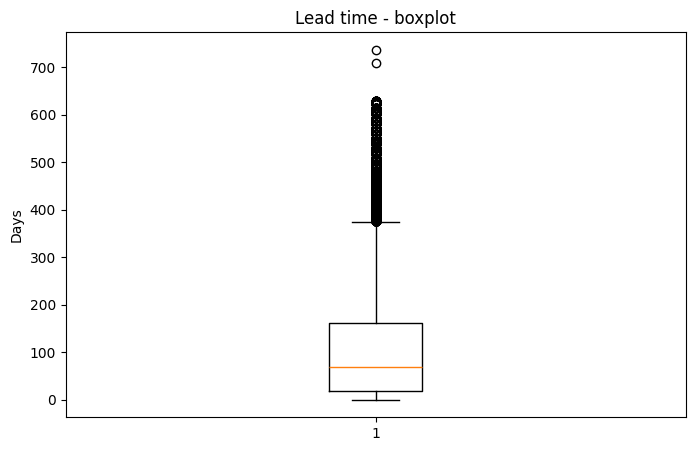

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["lead_time"].dropna())
plt.title("Lead time - boxplot")
plt.ylabel("Days")
plt.show()

**ADR IQR analysis**

Detecting potential ADR outliers
The Interquartile Range (IQR) method is applied to adr to identify observations outside the conventional lower and upper outlier boundaries.

In [ ]:
# IQR method for ADR

Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

adr_outliers = df[
    (df["adr"] < lower) |
    (df["adr"] > upper)
]

print(
    "Potential ADR outliers:",
    adr_outliers.shape[0]
)

print(
    "Lower bound:",
    lower
)

print(
    "Upper bound:",
    upper
)

Potential ADR outliers: 3864
Lower bound: -15.25
Upper bound: 210.75


**Negative ADR**

Inspecting negative ADR values
Reservations with a negative Average Daily Rate are examined because negative hotel prices are not meaningful in the context of the analysis.

In [ ]:
display(
    df[
        df["adr"] < 0
    ]
)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,2,No Deposit,273,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


**Highest ADR values**

Inspecting the highest ADR values
The ten observations with the highest Average Daily Rate are displayed together with selected booking characteristics to assess whether extreme values should be considered valid observations or potential anomalies.

In [ ]:
display(
    df.nlargest(
        10,
        "adr"
    )[
        [
            "hotel",
            "adr",
            "adults",
            "children",
            "stays_in_weekend_nights",
            "stays_in_week_nights"
        ]
    ]
)

,hotel,adr,adults,children,stays_in_weekend_nights,stays_in_week_nights
48515,City Hotel,5400.00,2,0,0,1
111403,City Hotel,510.00,1,0,0,1
15083,Resort Hotel,508.00,2,0,0,1
103912,City Hotel,451.50,2,2,1,1
13142,Resort Hotel,450.00,2,0,4,10
13391,Resort Hotel,437.00,2,2,2,4
39155,Resort Hotel,426.25,2,2,2,6
39568,Resort Hotel,402.00,3,1,2,3
39118,Resort Hotel,397.38,3,2,3,5
13323,Resort Hotel,392.00,2,1,2,8


**Removing negative ADR**

Removing invalid ADR values
Observations with negative ADR are removed. High positive ADR values are retained because extreme values do not necessarily represent errors.

In [ ]:
df = df[
    df["adr"] >= 0
].copy()

print(
    "Dataset shape after ADR cleaning:",
    df.shape
)

Dataset shape after ADR cleaning: (119205, 31)


**Creating total_nights**

Feature engineering: total number of nights
A new feature called total_nights is created by adding weekend-night stays and weekday-night stays.

In [ ]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

**Creating total_guests**

Feature engineering: total number of guests
The total number of guests is calculated as the sum of adults, children, and babies.

In [ ]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

**Creating previous_bookings**

Feature engineering: previous booking activity
A new feature representing the total number of previous bookings is created by combining previous canceled and previous non-canceled bookings.

In [ ]:
df["previous_bookings"] = (
    df["previous_cancellations"] +
    df["previous_bookings_not_canceled"]
)

**Creating room_changed**

Feature engineering: room assignment change
A binary variable is created to indicate whether the room assigned to the guest differs from the originally reserved room type.

In [ ]:
df["room_changed"] = (
    df["reserved_room_type"] !=
    df["assigned_room_type"]
).astype(int)

**Creating season**

Feature engineering: season of arrival
Arrival months are grouped into four seasons: Winter, Spring, Summer, and Autumn. This creates a higher-level representation of seasonal booking patterns.

In [ ]:
season_map = {
    "December": "Winter",
    "January": "Winter",
    "February": "Winter",

    "March": "Spring",
    "April": "Spring",
    "May": "Spring",

    "June": "Summer",
    "July": "Summer",
    "August": "Summer",

    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"
}

df["season"] = (
    df["arrival_date_month"]
    .map(season_map)
)

**Checking the new season feature**

Validating the season variable
This cell verifies that all arrival months were successfully mapped to a season and that no missing values were introduced.

In [ ]:
print(
    "Missing season values:",
    df["season"].isnull().sum()
)

Missing season values: 0


**Target-class counts**

Examining the target variable
The number of canceled and non-canceled reservations is calculated to inspect the distribution of the target variable is_canceled.

In [ ]:
display(
    df["is_canceled"]
    .value_counts()
)

,count
is_canceled,
0,75010
1,44195


**Target-class percentages**

Examining class proportions
The percentage distribution of canceled and non-canceled reservations is calculated to assess potential class imbalance.

In [ ]:
display(
    df["is_canceled"]
    .value_counts(normalize=True) * 100
)

,proportion
is_canceled,
0,62.925213
1,37.074787


**Cancellation bar chart**

Visualizing reservation cancellations
A bar chart compares the number of canceled and non-canceled reservations, providing a visual overview of the target-class distribution.

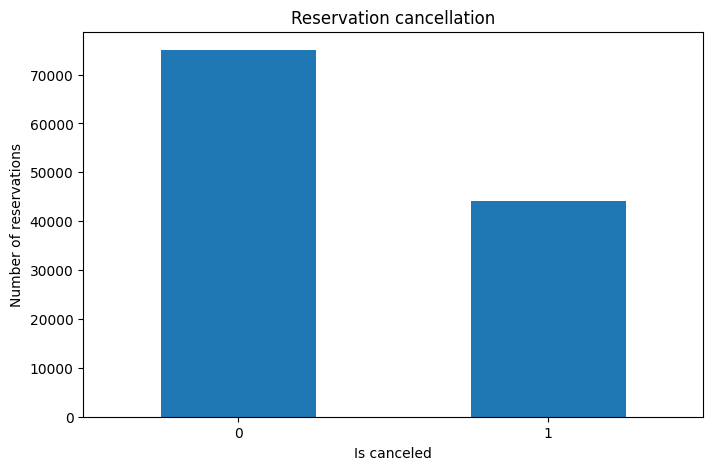

In [ ]:
plt.figure(
    figsize=(8, 5)
)

df["is_canceled"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Reservation cancellation"
)

plt.xlabel(
    "Is canceled"
)

plt.ylabel(
    "Number of reservations"
)

plt.xticks(rotation=0)

plt.show()

**Cancellation rate by hotel**

Cancellation rate by hotel type
A cross-tabulation is used to compare cancellation percentages between City Hotel and Resort Hotel.

In [ ]:
hotel_cancel = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
) * 100

display(hotel_cancel)

is_canceled,0,1
hotel,,
City Hotel,58.217006,41.782994
Resort Hotel,72.231933,27.768067


**Lead time and cancellation**

Lead time by cancellation status
The number of observations, mean lead time, and median lead time are calculated separately for canceled and non-canceled reservations.

In [ ]:
lead_time_summary = (
    df.groupby(
        "is_canceled"
    )["lead_time"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

display(
    lead_time_summary
)

,count,mean,median
is_canceled,,,
0,75010,80.080496,45.0
1,44195,144.899106,113.0


**Lead-time boxplot by target**

Comparing lead-time distributions
Boxplots are used to compare the distribution of lead time between canceled and non-canceled bookings.

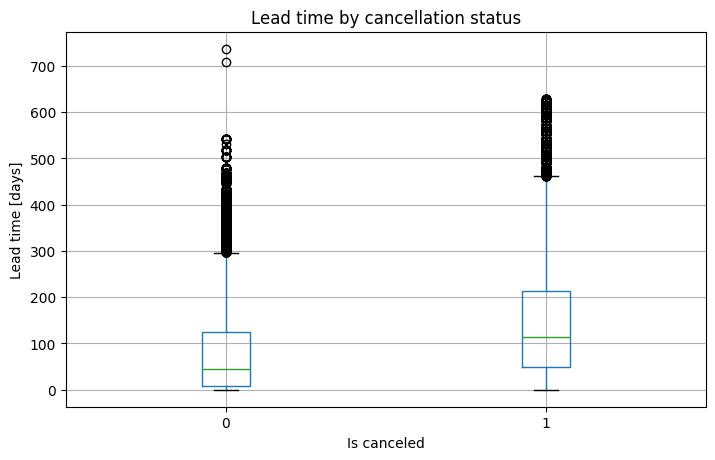

In [ ]:
df.boxplot(
    column="lead_time",
    by="is_canceled",
    figsize=(8, 5)
)

plt.title(
    "Lead time by cancellation status"
)

plt.suptitle("")

plt.xlabel(
    "Is canceled"
)

plt.ylabel(
    "Lead time [days]"
)

plt.show()

**ADR and cancellation**

ADR by cancellation status
The count, mean, and median ADR are calculated separately for canceled and non-canceled reservations. The median is included because ADR contains extreme values.

In [ ]:


adr_summary = (
    df.groupby(
        "is_canceled"
    )["adr"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

display(
    adr_summary
)

,count,mean,median
is_canceled,,,
0,75010,100.170632,92.7
1,44195,105.030528,96.3


**Monthly booking counts**

Calculating monthly booking frequency
Months are placed in chronological order and the number of bookings recorded in each month is calculated.

In [ ]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_bookings = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

**Monthly booking chart**

Visualizing booking seasonality
A bar chart shows the number of reservations by arrival month, allowing seasonal booking patterns to be identified.

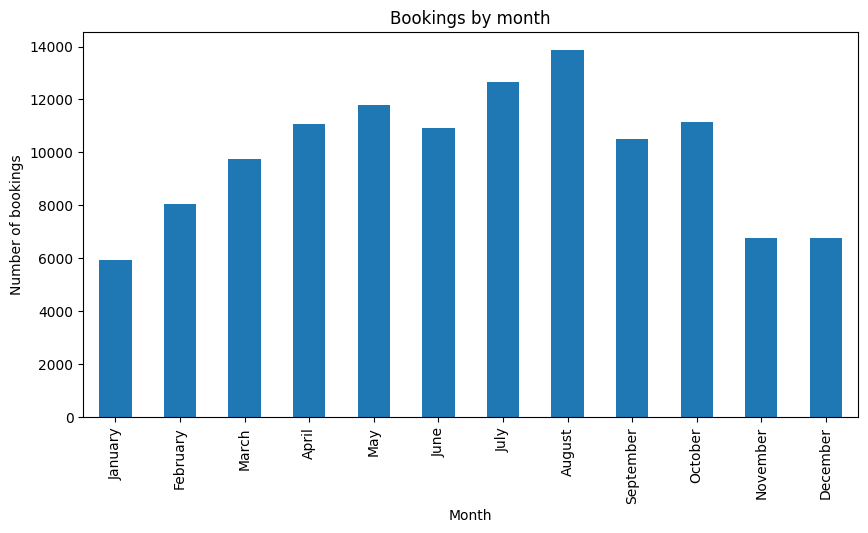

In [ ]:
monthly_bookings.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Bookings by month"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Number of bookings"
)

plt.xticks(
    rotation=90
)

plt.show()

**Market-segment cancellation rates**

Cancellation rate by market segment
Cancellation rates and booking counts are calculated for each market segment. The cancellation rate is also converted to percentage form to make the results easier to interpret.

In [ ]:
segment_summary = (
    df.groupby(
        "market_segment"
    )["is_canceled"]
    .agg(
        cancellation_rate="mean",
        bookings="count"
    )
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)



segment_summary[
    "cancellation_rate_percent"
] = (
    segment_summary[
        "cancellation_rate"
    ] * 100
)

display(
    segment_summary
)

,cancellation_rate,bookings,cancellation_rate_percent
market_segment,,,
Groups,0.611117,19790,61.111673
Online TA,0.367578,56407,36.757849
Offline TA/TO,0.343313,24182,34.331321
Aviation,0.221277,235,22.127660
Corporate,0.187618,5282,18.761833
Direct,0.153644,12581,15.364438
Complementary,0.122253,728,12.225275


**Selecting numerical features**

Preparing numerical variables for correlation analysis
Numerical variables are selected from the cleaned dataset and a Pearson correlation matrix is calculated.

In [ ]:
numeric_df = (
    df.select_dtypes(
        include=np.number
    )
)

corr = numeric_df.corr()

**Correlation heatmap**

Visualizing numerical correlations
The correlation matrix is displayed as a heatmap. The scale is fixed between -1 and 1 because Pearson correlation coefficients always fall within this range.

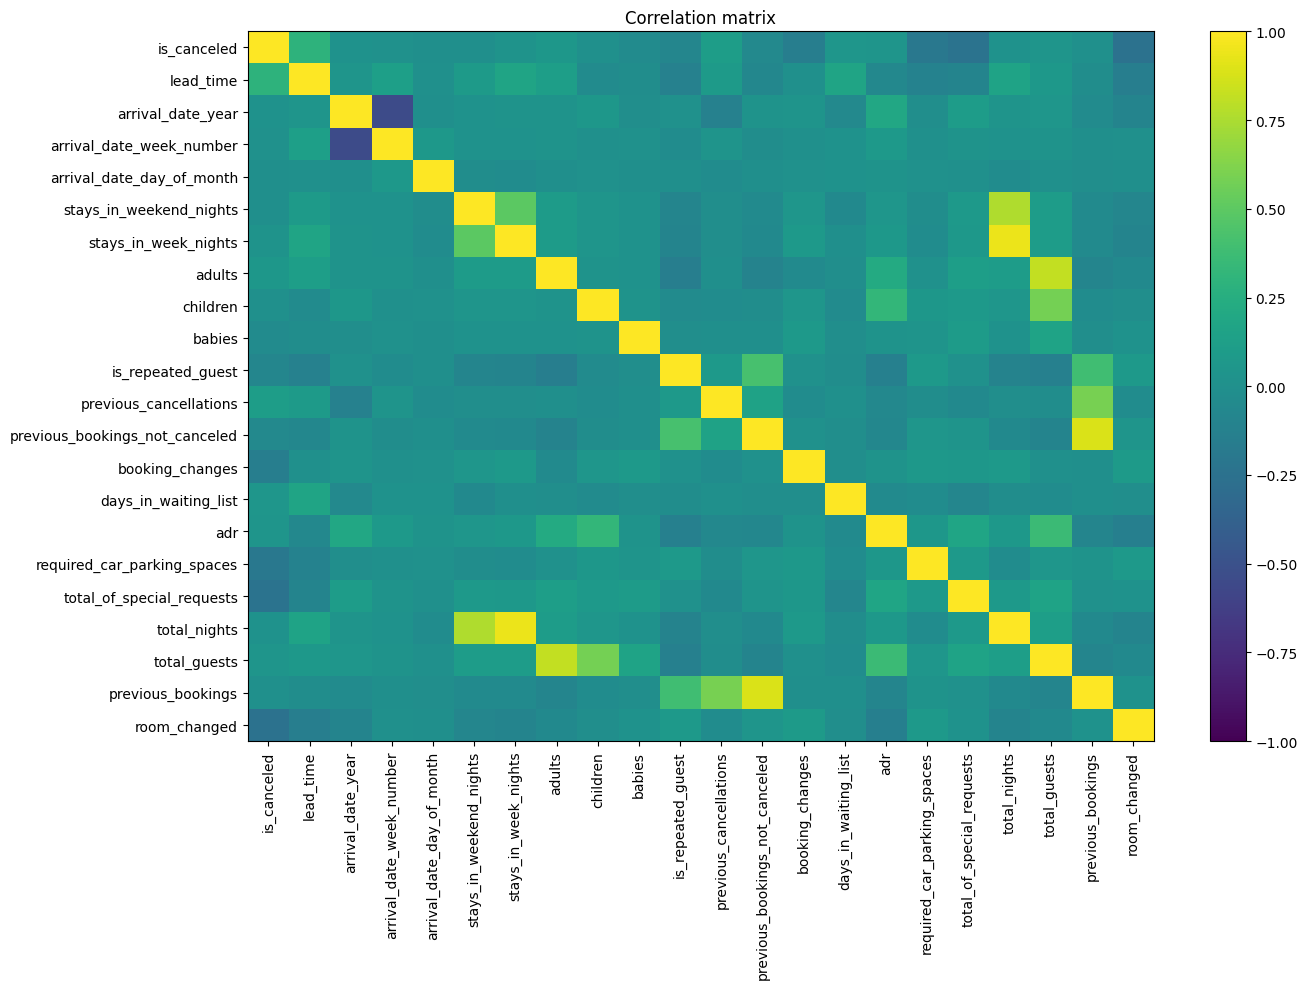

In [ ]:
plt.figure(
    figsize=(14, 10)
)



plt.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation matrix"
)

plt.tight_layout()

plt.show()

**Correlation with is_canceled**

Correlations with the target variable
Correlations between numerical features and is_canceled are extracted and sorted. The target's correlation with itself is removed because it is always equal to 1.

In [ ]:


target_corr = (
    corr["is_canceled"]
    .drop("is_canceled")
    .sort_values(
        ascending=False
    )
)

display(
    target_corr
)

,is_canceled
lead_time,0.292937
previous_cancellations,0.110147
adults,0.058157
days_in_waiting_list,0.054308
adr,0.046545
total_guests,0.044811
stays_in_week_nights,0.025561
total_nights,0.018579
arrival_date_year,0.016702
arrival_date_week_number,0.008291


**Absolute correlations**

Ranking correlations by strength
Features are sorted according to the absolute magnitude of their correlation with is_canceled. This allows both positive and negative relationships to be compared according to their strength.

In [ ]:


target_corr_absolute = (
    corr["is_canceled"]
    .drop("is_canceled")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(
    "Strongest correlations with is_canceled:"
)

display(
    target_corr_absolute
)

Strongest correlations with is_canceled:


,is_canceled
lead_time,0.292937
room_changed,-0.246750
total_of_special_requests,-0.234931
required_car_parking_spaces,-0.195698
booking_changes,-0.144808
previous_cancellations,0.110147
is_repeated_guest,-0.083715
adults,0.058157
previous_bookings_not_canceled,-0.057355
days_in_waiting_list,0.054308


**Creating df_model**

Removing direct target-leakage variables
reservation_status and reservation_status_date are excluded from the modeling dataset because they contain information about the final outcome of a reservation and would cause data leakage when predicting cancellation.

In [ ]:


df_model = df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ]
).copy()

**Creating df_prediction**

Creating the prediction dataset
Additional variables that may not be reliably available at the moment a reservation is created are removed. This creates a more realistic dataset for predicting future cancellations.

assigned_room_type, room_changed, booking_changes, and days_in_waiting_list are excluded to reduce the risk of using information generated after the initial booking.

In [ ]:


df_prediction = df_model.drop(
    columns=[
        "assigned_room_type",
        "room_changed",
        "booking_changes",
        "days_in_waiting_list"
    ]
).copy()

**Final dataset verification**

Verifying the cleaned datasets
The dimensions of the original, cleaned, and prediction datasets are compared. Missing values are also checked to confirm that preprocessing has produced complete datasets.

In [ ]:
print(
    "Original dataset shape:",
    df_original.shape
)

print(
    "Cleaned dataset shape:",
    df_model.shape
)

print(
    "Prediction dataset shape:",
    df_prediction.shape
)

print(
    "Missing values in cleaned dataset:",
    df_model.isnull().sum().sum()
)

print(
    "Missing values in prediction dataset:",
    df_prediction.isnull().sum().sum()
)

display(
    df_model.head()
)

Original dataset shape: (119390, 32)
Cleaned dataset shape: (119205, 34)
Prediction dataset shape: (119205, 30)
Missing values in cleaned dataset: 0
Missing values in prediction dataset: 0


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,previous_bookings,room_changed,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,0,2,0,0,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,0,2,0,0,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,1,1,0,1,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,1,1,0,0,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,2,2,0,0,Summer


**Separating X and y**

Separating predictors and target
The prediction dataset is divided into input features (X) and the target variable (y). The target is_canceled is excluded from the predictor matrix.

In [ ]:


X = df_prediction.drop(
    columns=[
        "is_canceled"
    ]
)

y = df_prediction[
    "is_canceled"
]

**Train/test split**

Creating training and test sets
The data is divided into training and test sets using an 80/20 split. Stratification is applied to preserve approximately the same cancellation-class proportions in both subsets.

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**Checking train/test distributions**

Validating the train-test split
The dimensions of the training and test datasets and their target-class distributions are displayed to confirm that stratification worked correctly.

In [ ]:
print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "\nTraining target distribution:"
)

display(
    y_train.value_counts(
        normalize=True
    ) * 100
)

print(
    "\nTest target distribution:"
)

display(
    y_test.value_counts(
        normalize=True
    ) * 100
)

X_train shape: (95364, 29)
X_test shape: (23841, 29)

Training target distribution:


,proportion
is_canceled,
0,62.925213
1,37.074787



Test target distribution:


,proportion
is_canceled,
0,62.925213
1,37.074787


**Detecting feature types**

Identifying numerical and categorical predictors
Numerical and categorical features are identified from the training dataset. Feature types are determined only after separating the target variable.

In [ ]:


categorical_cols = (
    X_train
    .select_dtypes(
        include=["object"]
    )
    .columns
    .tolist()
)

numerical_cols = (
    X_train
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print(
    "Categorical variables:"
)

print(
    categorical_cols
)

print(
    "\nNumerical variables:"
)

print(
    numerical_cols
)

Categorical variables:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type', 'season']

Numerical variables:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'previous_bookings']


**Creating the preprocessing pipeline**

Building the preprocessing pipeline
A ColumnTransformer is created to apply standardization to numerical features and one-hot encoding to categorical variables.

Unknown categories are ignored during transformation so that categories appearing only in the test or future data do not cause an error.

In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

**Fitting preprocessing on training data**

Fitting preprocessing on the training set
The scaler and encoder are fitted exclusively on the training dataset and the training features are transformed. This prevents information from the test set from influencing preprocessing.

In [ ]:


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

**Transforming test data**

The test data is transformed using the preprocessing parameters learned exclusively from the training set. The preprocessing pipeline is not fitted again on the test data.

In [ ]:


X_test_processed = (
    preprocessor.transform(
        X_test
    )
)

**Processed shapes**

Checking transformed dataset dimensions
The dimensions of the transformed training and test datasets are displayed to verify that both sets contain the same number of model features.

In [ ]:
print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed test shape:",
    X_test_processed.shape
)

Processed train shape: (95364, 563)
Processed test shape: (23841, 563)


**Feature names**

Inspecting transformed feature names
The names of features created by the preprocessing pipeline are retrieved. This makes it possible to identify both standardized numerical variables and dummy variables generated by one-hot encoding.

In [ ]:


feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Number of model features:",
    len(feature_names)
)

print(
    "\nFirst 30 model features:"
)

print(
    feature_names[:30]
)

Number of model features: 563

First 30 model features:
['num__lead_time' 'num__arrival_date_year' 'num__arrival_date_week_number'
 'num__arrival_date_day_of_month' 'num__stays_in_weekend_nights'
 'num__stays_in_week_nights' 'num__adults' 'num__children' 'num__babies'
 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__adr'
 'num__required_car_parking_spaces' 'num__total_of_special_requests'
 'num__total_nights' 'num__total_guests' 'num__previous_bookings'
 'cat__hotel_City Hotel' 'cat__hotel_Resort Hotel'
 'cat__arrival_date_month_April' 'cat__arrival_date_month_August'
 'cat__arrival_date_month_December' 'cat__arrival_date_month_February'
 'cat__arrival_date_month_January' 'cat__arrival_date_month_July'
 'cat__arrival_date_month_June' 'cat__arrival_date_month_March'
 'cat__arrival_date_month_May' 'cat__arrival_date_month_November']


**Saving hotel_bookings_clean.csv**

Saving the cleaned analytical dataset
The cleaned dataset is exported to CSV. This version retains variables useful for exploratory data analysis but excludes direct target-leakage variables such as reservation status.

In [ ]:


df_model.to_csv(
    "hotel_bookings_clean.csv",
    index=False
)

**Saving hotel_bookings_prediction.csv**

Saving the prediction dataset
A second CSV file is created specifically for predictive modeling. Variables that may contain information unavailable at the moment of booking have been removed to reduce the risk of data leakage.

In [ ]:


df_prediction.to_csv(
    "hotel_bookings_prediction.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "hotel_bookings_clean.csv"
)

files.download(
    "hotel_bookings_prediction.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Logic**


Raw data

   ↓

Initial exploration

   ↓

Missing-value handling

   ↓

Data-quality checks

   ↓

Invalid observation removal

   ↓

Outlier investigation

   ↓

Feature engineering

   ↓

EDA

   ↓

Leakage analysis


   ↓

Prediction dataset

   ↓

X / y

   ↓

Train / test split

   ↓

Fit preprocessing ONLY on training data

   ↓

Transform training and test data

   ↓

Ready for machine-learning models

hotel_bookings_clean.csv → EDA / general analysis


hotel_bookings_prediction.csv → machine-learning prediction of is_canceled.